# End-2024 compute backcasts for the four frontier labs

Extends the end-2025 Monte Carlo estimates one year back, and compares the two
years. The Google DeepMind and Meta backcasts are **canonical** (promoted
2026-07-10): their judgment priors live in `lab_model_params.csv` (the `*_2024`
rows) and the model structure in `frontier_lab_compute_model.py` section 5
(`model_deepmind_2024`, `model_msl_2024`), exported by `lab_compute_tables/`
alongside the end-2025 rows. This notebook is the walkthrough and cross-lab
comparison — it restates no priors.

| Lab | End-2024 method | Status |
|---|---|---|
| OpenAI | canonical power model, 600 MW disclosure (already per-year) | canonical (frontier script) |
| Google DeepMind | owned fleet × data-driven deployment lag × **single** DM share | canonical (frontier script) |
| Meta AI (pre-MSL) | owned fleet × data-driven deployment lag × frontier share | canonical (frontier script) |
| Anthropic | spend-curve backcast, imported from `anthropic_2024_backcast` | notebook-only, not exported |

**Definitional convention:** "the lab" in 2024 means *frontier-AI compute at the
company*. Meta Superintelligence Labs did not exist in 2024 — its predecessor
was Meta AI / GenAI plus FAIR — and Google DeepMind is the post-April-2023
merged organization. The share priors (from the 2026-07-10 writeup) are for
those predecessor scopes.

In [1]:
import contextlib
import io
import runpy
import sys
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import squigglepy as sq

HERE = Path('.') if Path('frontier_lab_compute_model.py').exists() else Path('ai-lab-compute')
sys.path.insert(0, str(HERE.resolve()))
import frontier_lab_compute_model as frontier

LAB_COLORS = {'Google DeepMind': '#2B8C86', 'Meta AI / MSL': '#2B6CB8',
              'OpenAI': '#1a73e8', 'Anthropic': '#e8710a'}


def fmt(value):
    """Format an H100e count as a short string (millions or thousands)."""
    if abs(value) >= 1e6:
        return f'{value / 1e6:.2f}M'
    return f'{value / 1e3:,.0f}k'


def percentiles(samples):
    """Return (5th, 50th, 95th) percentiles of a sample array."""
    p = sq.get_percentiles(samples, percentiles=[5, 50, 95])
    return p[5], p[50], p[95]


def show(label, samples):
    lo, mid, hi = percentiles(samples)
    print(f'   {label:34s}: {fmt(lo)} / {fmt(mid)} / {fmt(hi)}')

## 0. Anchors from the canonical frontier script

Every distribution in this notebook comes from a canonical script: the
frontier models each reseed the global squigglepy stream internally, so they
reproduce their canonical runs regardless of cell order, and this notebook
draws no samples of its own. (The Anthropic backcast script, executed in
section 5, seeds its own stream too.)

In [2]:
openai_res = frontier.model_openai()
openai_by_date = openai_res['total_h100e_by_date']
end2025 = {
    'Google DeepMind': frontier.model_deepmind(),
    'Meta AI / MSL': frontier.model_msl(),
    'OpenAI': openai_res['total_h100e'],
    'Anthropic': frontier.model_anthropic(openai_res),
}

print('End-2025 anchors (canonical script, current tree):')
for lab, samples in end2025.items():
    show(lab, samples)

End-2025 anchors (canonical script, current tree):
   Google DeepMind                   : 1.01M / 1.58M / 2.55M
   Meta AI / MSL                     : 602k / 988k / 1.63M
   OpenAI                            : 1.17M / 1.76M / 2.23M
   Anthropic                         : 936k / 1.21M / 1.57M


## 1. OpenAI

Nothing new to model: the disclosed power series (200 / 600 / 1,900 MW) is
already per-year, and `model_openai` converts every disclosed year-end through
the same machinery (Microsoft chip mix under a deployment lag, power-definition
mixture, rounding jitter). We just read the end-2024 snapshot off the canonical
run. The 600 MW figure carries a ±50 MW rounding band (±8%), so end-2024 is
relatively better-pinned than end-2023 (±25%) — and it is mostly a Hopper fleet
with a legacy A100 tail, before any Blackwell.

In [3]:
openai_2024 = openai_by_date[[d for d in openai_by_date if d.year == 2024][0]]
print('OpenAI end-of-year totals (canonical power model):')
for date, samples in openai_by_date.items():
    show(str(date.date()), samples)

OpenAI end-of-year totals (canonical power model):
   2023-12-31                        : 66k / 100k / 135k
   2024-12-31                        : 257k / 386k / 491k
   2025-12-31                        : 1.17M / 1.76M / 2.23M


## 2. Owned fleets and the deployment lag (DeepMind, Meta)

Same top-down structure as the 2025 models: owned fleet (sold basis, from the
AI Chip Owners dashboards) × an operational/owned ratio × a lab share. Two
differences in how the canonical backcasts get the first two factors:

- **Owned fleets** are read straight from the quarterly dashboard CSVs at
  end-2024, as lognormals through the summed per-chip 5th/95th columns.
  (Summing per-chip percentile bounds treats chips as perfectly correlated, so
  these CIs are on the generous side — same convention the 2025 sheet rows
  effectively used.)
- **The operational/owned ratio is computed from the data, not hand-derived.**
  The 2025 sheet ratios (e.g. 0.55–0.87 for Google) were derived from the 2025
  growth trajectory and would overstate early years: fleets grew ~3.5–4.5×
  during 2024, so a given install lag shaves more. The models sample the lag
  itself (the `lag_quarters_2024` sheet rows, 0.5–2 quarters — the OpenAI
  model's prior) and read the owned stock that many quarters before end-2024
  off the interpolated quarterly series.

Both models live in `frontier_lab_compute_model.py`; each records its
intermediate quantities in `MODEL_STEPS`, which the cells below read back.

In [4]:
deepmind_2024 = frontier.model_deepmind_2024()
meta_2024 = frontier.model_msl_2024()
dm_steps = {s['name']: s for s in frontier.MODEL_STEPS['deepmind_2024']}
meta_steps = {s['name']: s for s in frontier.MODEL_STEPS['msl_2024']}

# Rebuild the owned-stock trajectories the models read their lag ratios off,
# to show the ratio at a few fixed lags. The Meta trajectory folds in the AMD
# slice at the sampled share's median, as the model does.
google_stock = (frontier.owner_quarterly_h100e_medians(frontier.OWNERS_CSV, 'Google')
                + frontier.owner_quarterly_h100e_medians(frontier.TPU_CSV)).dropna()
meta_nvidia_stock = frontier.owner_quarterly_h100e_medians(frontier.OWNERS_CSV, 'Meta')
meta_amd_stock = (frontier.owner_quarterly_h100e_medians(frontier.AMD_CSV)
                  .reindex(meta_nvidia_stock.index).fillna(0.0))
meta_amd_share_med = float(np.median(meta_steps['meta_amd_share_2024']['samples']))
meta_stock = (meta_nvidia_stock + meta_amd_share_med * meta_amd_stock).dropna()

print('Operational/owned ratio at fixed lags (from the 2024 trajectories):')
for lag in [0.5, 1.0, 2.0]:
    r_g = frontier.operational_ratio_2024(google_stock, np.array([lag]))[0]
    r_m = frontier.operational_ratio_2024(meta_stock, np.array([lag]))[0]
    print(f'   {lag:3.1f} quarters: Google {r_g:.2f}, Meta {r_m:.2f}   (2025-model sheet medians were ~0.69 / ~0.75)')
for lab, steps in [('Google', dm_steps), ('Meta', meta_steps)]:
    lo, mid, hi = percentiles(steps['deployment_lag']['samples'])
    print(f'Sampled ratio, {lab + ":":<7} {lo:.2f} / {mid:.2f} / {hi:.2f}')

Operational/owned ratio at fixed lags (from the 2024 trajectories):
   0.5 quarters: Google 0.85, Meta 0.84   (2025-model sheet medians were ~0.69 / ~0.75)
   1.0 quarters: Google 0.70, Meta 0.68   (2025-model sheet medians were ~0.69 / ~0.75)
   2.0 quarters: Google 0.51, Meta 0.47   (2025-model sheet medians were ~0.69 / ~0.75)
Sampled ratio, Google: 0.51 / 0.71 / 0.85
Sampled ratio, Meta:   0.47 / 0.68 / 0.84


## 3. Meta AI (pre-MSL frontier compute), end-2024

Share prior **0.25–0.80** (median ~0.45), clipped to [0.1, 0.9] — the
`msl,meta_ai_share_2024` sheet row, widened at the bottom from 2025's
0.33–0.80 (median ~0.51). Reasoning from the writeup:

- MSL didn't exist in 2024; Meta AI (fka FAIR) plus GenAI covered
  frontier/fundamental work, with unclear organizational separation from ads.
- SemiAnalysis attributes a very low share of Meta's AI compute to "Meta
  Superintelligence" historically, but the label is hard to interpret pre-2025.
- The hard anchor the other way: Meta disclosed a **100k-H100 training cluster
  by late 2024** (plus two earlier 24k clusters and Llama-405B on 16k H100s),
  against a total owned fleet of roughly 500–800k H100e — so a >20% frontier
  share is very likely.
- Net: Meta AI in 2024 likely ran a *lower* share than MSL did in 2025.

The owned fleet adds a slice of the all-owner AMD Instinct fleet (the
dashboards don't split AMD by owner): the `msl,meta_amd_share_2024` sheet row,
0.30–0.55 — Meta was the flagship MI300X customer in 2024, with ~173k units
reported (roughly 40–50% of shipments); Microsoft and Oracle took most of the
rest.

In [5]:
print('Meta AI end-2024 (canonical model_msl_2024):')
for name in ['nvidia_owned', 'amd_owned', 'operational', 'total_h100e']:
    show(meta_steps[name]['label'], meta_steps[name]['samples'])
print(f'   P(below the 100k-H100-cluster floor): {np.mean(meta_2024 < 100e3):.1%}')

Meta AI end-2024 (canonical model_msl_2024):
   Meta-owned Nvidia fleet           : 448k / 603k / 804k
   Meta-owned AMD Instinct fleet     : 152k / 220k / 320k
   Operational fleet                 : 368k / 562k / 778k
   Meta AI frontier compute, end-2024: 124k / 248k / 480k
   P(below the 100k-H100-cluster floor): 2.0%


## 4. Google DeepMind, end-2024

Structural change from the 2025 model: **one share, not two.** The 2025 model
split Google's fleet into a cloud half and an internal half because the CFO
said the split was "around half" — but Google made no such statement for 2024,
so the two-sub-share blend has nothing to anchor on and the model samples
DeepMind's overall share of Google ML compute directly.

Share prior **0.25–0.75** (median ~0.43), clipped to [0.1, 0.9] — the
`deepmind,dm_share_2024` sheet row. Anchors from the writeup: SemiAnalysis's
Meta-Superintelligence piece shows DeepMind (maybe R&D only) at ~0.72 GW of a
~2.2 GW Google total (~33%, via plot digitizer), and DeepMind + "Google
Services AI" at ~55% — if half of Services AI is DeepMind-related inference,
~44%. (GW basis, not H100e, but roughly proportional.) Not to be taken too
literally, but plausible; the interval is set similar to — somewhat wider
than — the 2025 model's implied overall DeepMind share of 0.32–0.67.
https://newsletter.semianalysis.com/p/the-future-of-meta-superintelligence

In [6]:
print('Google DeepMind end-2024 (canonical model_deepmind_2024):')
for name in ['nvidia_owned', 'google_owned', 'operational', 'total_h100e']:
    show(dm_steps[name]['label'], dm_steps[name]['samples'])

Google DeepMind end-2024 (canonical model_deepmind_2024):
   Google-owned Nvidia fleet         : 322k / 433k / 577k
   Google TPU fleet                  : 682k / 922k / 1.26M
   Operational fleet                 : 654k / 965k / 1.30M
   DeepMind compute, end-2024        : 215k / 423k / 779k


## 5. Anthropic, end-2024 — imported from `anthropic_2024_backcast`

Anthropic's backcast has its own notebook, `anthropic_2024_backcast.py`
(consolidating what was §9 of the cloud-spend notebook and an earlier version
of this section). The model in one line: start from the power-anchored
end-2025 fleet and shrink it twice — once because Anthropic was spending less
at the end of 2024 (~0.37x the end-2025 rate), and once because each 2024
dollar bought less compute (~0.56x). See that notebook for the printed and
charted intermediates, the SemiAnalysis cross-checks, and the factor
decomposition. Here we just execute it quietly and import the samples.

In [7]:
def load_anthropic_2024():
    """Execute the Anthropic backcast notebook script and return its end-2024
    samples, without letting its prints or charts render here."""
    path = ('anthropic_2024_backcast.py' if Path('anthropic_2024_backcast.py').exists()
            else 'ai-lab-compute/anthropic_2024_backcast.py')
    original_show = plt.show
    plt.show = lambda *args, **kwargs: None
    try:
        with contextlib.redirect_stdout(io.StringIO()), warnings.catch_warnings():
            warnings.simplefilter('ignore')
            namespace = runpy.run_path(path)
    finally:
        plt.show = original_show
        plt.close('all')
    return namespace['anthropic_2024']


anthropic_2024 = load_anthropic_2024()
show('ANTHROPIC H100e (imported)', anthropic_2024)

   ANTHROPIC H100e (imported)        : 121k / 249k / 428k


## 6. Results: the four labs, end-2024 vs end-2025

In [8]:
end2024 = {
    'Google DeepMind': deepmind_2024,
    'Meta AI / MSL': meta_2024,
    'OpenAI': openai_2024,
    'Anthropic': anthropic_2024,
}

print(f'{"Lab":<18}{"end-2024 (5/50/95)":>28}{"end-2025 (5/50/95)":>28}{"growth":>9}')
for lab in end2024:
    lo4, mid4, hi4 = percentiles(end2024[lab])
    lo5, mid5, hi5 = percentiles(end2025[lab])
    print(f'{lab:<18}{fmt(lo4):>9} /{fmt(mid4):>7} /{fmt(hi4):>7}'
          f'{fmt(lo5):>10} /{fmt(mid5):>7} /{fmt(hi5):>7}{mid5 / mid4:>8.1f}x')

Lab                         end-2024 (5/50/95)          end-2025 (5/50/95)   growth
Google DeepMind        215k /   423k /   779k     1.01M /  1.58M /  2.55M     3.7x
Meta AI / MSL          124k /   248k /   480k      602k /   988k /  1.63M     4.0x
OpenAI                 257k /   386k /   491k     1.17M /  1.76M /  2.23M     4.5x
Anthropic              121k /   249k /   428k      936k /  1.21M /  1.57M     4.9x


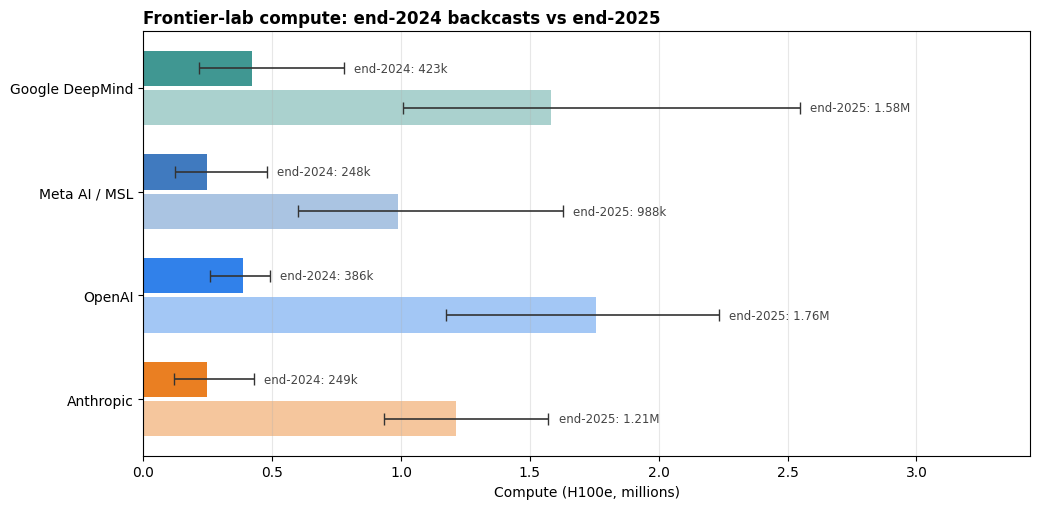

In [9]:
fig, ax = plt.subplots(figsize=(10.5, 5.2))
labs = list(end2024)
for i, lab in enumerate(labs):
    y = len(labs) - 1 - i
    for offset, samples, alpha, label in [(0.19, end2024[lab], 0.9, 'end-2024'),
                                          (-0.19, end2025[lab], 0.4, 'end-2025')]:
        lo, mid, hi = percentiles(samples)
        ax.barh(y + offset, mid / 1e6, height=0.34, color=LAB_COLORS[lab], alpha=alpha)
        ax.errorbar(mid / 1e6, y + offset, xerr=[[(mid - lo) / 1e6], [(hi - mid) / 1e6]],
                    fmt='none', ecolor='#333333', elinewidth=1.2, capsize=4)
        ax.text(hi / 1e6 + 0.04, y + offset, f'{label}: {fmt(mid)}', va='center',
                fontsize=8.5, color='#444444')
ax.set_yticks(range(len(labs)))
ax.set_yticklabels(list(reversed(labs)))
ax.set_xlabel('Compute (H100e, millions)')
ax.set_title('Frontier-lab compute: end-2024 backcasts vs end-2025', loc='left', weight='bold')
ax.set_xlim(0, max(percentiles(s)[2] for s in end2025.values()) / 1e6 * 1.35)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## 7. Caveats and next steps

- **The lab shares are the weakest inputs**, as in 2025 — and for 2024 they are
  also definitionally fuzzier (pre-MSL Meta, one-share DeepMind). The
  SemiAnalysis attributions they lean on are themselves model outputs.
- **The lag ratios use the median owned-stock trajectory** — trajectory-shape
  uncertainty isn't propagated, only the level (fleet lognormals) and the lag.
- **Owned-fleet CIs sum per-chip percentile bounds** (perfect-correlation
  assumption, generous widths); the Meta AMD slice adds a rough share prior.
- **Anthropic is imported from `anthropic_2024_backcast`**, which documents
  its assumptions (a time-stable power-vs-spend correction, smooth exponential
  spend) and the SemiAnalysis cross-checks pointing to its lower half
  (~190–230k).
- **OpenAI's numbers move with the in-flight openai-notebook work** (the
  current tree's end-2025 CI is wider than the 7/2 docs); this notebook always
  reports the current canonical script.
- **Promoted 2026-07-10:** the DeepMind and Meta priors live in
  `lab_model_params.csv` (`*_2024` rows), the models in the frontier script
  (section 5), and `lab_compute_tables` exports the extra (lab × year) rows in
  both tables and the consolidated page (`build_compute_page.py` →
  `index.html`). Anthropic's backcast deliberately stays notebook-only —
  promote it the same way if it should ship.